In [ ]:
from google.colab import files
import pandas as pd

# Upload dataset
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract Month
df['Month'] = df['Date'].dt.to_period('M')

# Calculate month-wise total profit
monthly_profit = df.groupby('Month')['Profit'].sum().reset_index()

# Get previous month profit
monthly_profit['Prev_Month_Profit'] = monthly_profit['Profit'].shift(1)

# Predict Profit or Loss for next month
def predict_next(row):
    if pd.isna(row['Prev_Month_Profit']):
        return "No Previous Data"
    elif row['Profit'] >= row['Prev_Month_Profit']:
        return "Likely Profit Next Month"
    else:
        return "Likely Loss Next Mont6h"

monthly_profit['Prediction'] = monthly_profit.apply(predict_next, axis=1)

print("MONTH-WISE PROFIT WITH PREDICTION")
print(monthly_profit)

Saving large_sales_data (1).csv to large_sales_data (1).csv
MONTH-WISE PROFIT WITH PREDICTION
     Month  Profit  Prev_Month_Profit                Prediction
0  2024-01  763909                NaN          No Previous Data
1  2024-02  689548           763909.0   Likely Loss Next Mont6h
2  2024-03  701993           689548.0  Likely Profit Next Month
3  2024-04  730799           701993.0  Likely Profit Next Month
4  2024-05  100916           730799.0   Likely Loss Next Mont6h


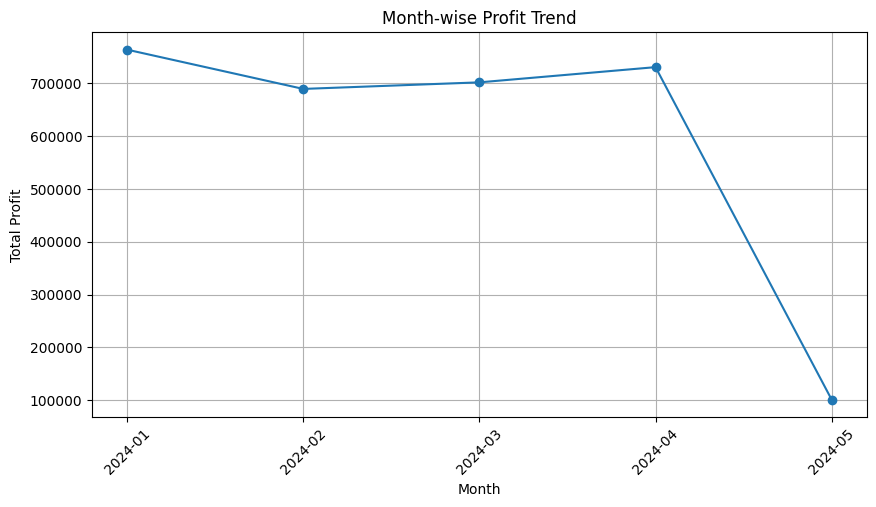

In [ ]:
import matplotlib.pyplot as plt

# Convert Month to string for proper plotting
monthly_profit['Month'] = monthly_profit['Month'].astype(str)

# Create line graph
plt.figure(figsize=(10, 5))
plt.plot(monthly_profit['Month'], monthly_profit['Profit'], marker='o')

plt.title("Month-wise Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()